# Robust iSWAP Gate — 150 ns total (5 ns Gaussian + 10 ns buffer + 120 ns flat-top + 10 ns buffer + 5 ns Gaussian)

Same physics and optimization knobs as `robust_iswap_detuned_2MHz_100ns.ipynb`, but with
**hardware-respecting buffer structure**:

| Region | Duration | g_eff | Microwaves | Notes |
|---|---|---|---|---|
| Gaussian rise | 5 ns | ramping 0 → on | OFF | σ_rise = 1.25 ns → 4σ buffer = 5 ns (BW ≈ 127 MHz) |
| Buffer | 10 ns | on | OFF | flat at g_eff, microwave-free settling region |
| Flat-top | **120 ns** | on | **applied (optimized)** | this is the optimization region |
| Buffer | 10 ns | on | OFF | symmetric flat-top continuation |
| Gaussian fall | 5 ns | ramping on → 0 | OFF | |
| **Total** | **150 ns** | | | |

`V_rise` and `V_fall` now bundle the Gaussian + 10 ns square buffer together: each is
`exp(-i · (A_gauss + g_eff · 10) · (XX+YY))`. The 120 ns microwave-applied region is what
`VariationalSplinePulseProblem` optimizes over.

All other parameters identical to the 100 ns notebook: `g_eff = 2 MHz`, `δ₁₂ = 60 MHz`,
`a_bound = 10 MHz`, `Q = 0`, `Q_r = 1e2`, `R = 1e-3`, `F_threshold = 0.9999`, `N_knots = 24`,
`num_iter = 1000`, seed = 42, ZI/IZ/ZZ variational robustness, detuned drives at gate frame.

## 1. Imports

In [1]:
import Pkg
Pkg.activate(".")
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt", "FFTW"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [2]:
using Revise
using Piccolo
using LinearAlgebra
using Random
using Printf
using CairoMakie
using FFTW

## 2. Parameters

In [3]:
# --- Pauli operators ---
XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
YI = operator_from_string("YI")
IX = operator_from_string("IX")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

# --- Physical parameters ---
g_eff = 2π * 0.002       # flat-top coupling: 2 MHz in rad/ns
δ₁₂ = 2π * 0.06          # idle detuning: 60 MHz in rad/ns

# --- Drive detunings from gate frame (ω₁) ---
Δ_mw1 = -2π * 0.00     # 0 MHz
Δ_mw2 = +2π * 0.00     # 0 MHz

# --- Control bounds ---
a_bound = 2π * 0.01     # 10 MHz microwave amplitude bound
drive_bounds = fill(a_bound, 4)  # 4 microwave channels (no g_eff channel)

# --- Gaussian edge parameters ---
# 5 ns Gaussian rising/falling edge: σ_rise = 5/4 = 1.25 ns so that 4σ buffer = 5 ns.
# Bandwidth ≈ 1/(2π·σ) ≈ 127 MHz — comfortably inside the 250 MHz AWG filter.
σ_rise = 1.25                       # ns

# --- Buffer between Gaussian edge and microwave-on region ---
# 10 ns of g_eff fully on, microwaves OFF. Hardware-imposed settling time.
buffer_flat_duration = 10.0         # ns

# --- Gate target ---
U_iswap = exp(-im * π/4 * (XX + YY))

# --- Optimization parameters ---
F_threshold = 0.9999
Q_r = 1e2             # robustness weight
T_total_ns  = 120.0     # microwave-applied flat-top duration (ns) — the optimization region
n_samples = 300         # spline interpolation samples
N_knots = 24            # spline knot points
num_iter = 1000

println("g_eff = ", round(g_eff/(2π)*1e3, digits=1), " MHz")
println("δ₁₂ = ", round(δ₁₂/(2π)*1e3, digits=1), " MHz")
println("Δ_mw1 = ", round(Δ_mw1/(2π)*1e3, digits=1), " MHz")
println("Δ_mw2 = ", round(Δ_mw2/(2π)*1e3, digits=1), " MHz")
println("a_bound = ", round(a_bound/(2π)*1e3, digits=1), " MHz")
println("σ_rise = ", σ_rise, " ns (4σ Gaussian edge = ", 4*σ_rise, " ns, BW ≈ ",
        round(1/(2π*σ_rise*1e-9)/1e6, digits=0), " MHz)")
println("buffer_flat_duration = ", buffer_flat_duration, " ns (g_eff on, no microwaves)")
println("T_total_ns (microwave region) = ", T_total_ns, " ns")
println("Total gate time = ", 2*4*σ_rise + 2*buffer_flat_duration + T_total_ns, " ns")

g_eff = 2.0 MHz
δ₁₂ = 60.0 MHz
Δ_mw1 = -0.0 MHz
Δ_mw2 = 0.0 MHz
a_bound = 10.0 MHz
σ_rise = 1.25 ns (4σ Gaussian edge = 5.0 ns, BW ≈ 127.0 MHz)
buffer_flat_duration = 10.0 ns (g_eff on, no microwaves)
T_total_ns (microwave region) = 120.0 ns
Total gate time = 150.0 ns


## 3. Compute V_rise, V_fall, and U_goal

The Gaussian edges produce pure XX+YY rotations. Since the qubits are
on-resonance during the gate, V depends only on the integrated area.

```
V_rise = exp(-i A_rise (XX+YY))
V_fall = exp(-i A_fall (XX+YY))
U_goal = exp(-i (π/4 - A_rise - A_fall) (XX+YY))
```

In [4]:
# --- Gaussian edge envelope ---
# g(t) = g_eff * exp(-(t - t_center)² / (2σ²)), truncated at ±4σ.

buffer_duration = 4 * σ_rise        # ns — width of the Gaussian-shaped portion (5 ns)
dt_fine = 0.01                       # fine grid for integration (ns)

t_rise = collect(0:dt_fine:buffer_duration)
g_rise = g_eff .* exp.(-(t_rise .- buffer_duration).^2 ./ (2 * σ_rise^2))
# At t=0: g ≈ 0 (4σ away). At t=buffer_duration: g = g_eff (fully on).

t_fall = collect(0:dt_fine:buffer_duration)
g_fall = g_eff .* exp.(-(t_fall).^2 ./ (2 * σ_rise^2))

# --- Integrated areas ---
# A_gauss : area of the Gaussian edge alone (single side)
# A_buffer: area of the 10 ns square-flat buffer at g_eff (single side)
# A_pre   : total pre-flat area (Gaussian rise + 10 ns buffer) before microwaves start
A_gauss  = sum(g_rise) * dt_fine
A_buffer = g_eff * buffer_flat_duration
A_pre    = A_gauss + A_buffer
A_post   = A_pre                       # symmetric: 10 ns buffer + Gaussian fall

println("A_gauss  (single Gaussian edge)         = ", round(A_gauss, digits=6), " rad")
println("A_buffer (single 10 ns flat at g_eff)   = ", round(A_buffer, digits=6), " rad")
println("A_pre    (rise + 10 ns buffer)          = ", round(A_pre, digits=6), " rad")
println("A_pre + A_post (consumed by edges+buffers) = ", round(A_pre + A_post, digits=6), " rad")
println("π/4                                     = ", round(π/4, digits=6), " rad")
println()

# --- Target rotation angle for the microwave-on flat-top ---
θ_goal = π/4 - A_pre - A_post
@assert θ_goal > 0 "Edges + buffers over-rotate past iSWAP! Reduce g_eff, σ_rise, or buffer_flat_duration."

println("θ_goal (rotation still needed in microwave region) = ", round(θ_goal, digits=6), " rad")
println("θ_goal / (π/4) = ", round(θ_goal / (π/4) * 100, digits=1), "% of full iSWAP")

# --- Build U_goal (microwave-region target) ---
U_goal = exp(-im * θ_goal * (XX + YY))

# --- Build V_rise, V_fall (bundle Gaussian edge + 10 ns square buffer) ---
# Both regions are pure XX+YY drift evolution; they commute, so the total unitary
# is exp(-i · A_pre · (XX+YY)).
V_rise = exp(-im * A_pre  * (XX + YY))
V_fall = exp(-im * A_post * (XX + YY))

# --- Verify: V_fall · U_goal · V_rise = iSWAP ---
U_total = V_fall * U_goal * V_rise
F_check = abs(tr(U_iswap' * U_total)) / 4
println()
println("Verification: F(V_fall · U_goal · V_rise, iSWAP) = ", F_check)

# --- Flat-top duration estimate (from coupling alone, no microwaves) ---
T_flat_est = θ_goal / g_eff
println("Estimated flat-top duration (coupling only): ", round(T_flat_est, digits=2), " ns")

# --- Run tag (distinguishes the 5 ns + 10 ns + 120 ns + 10 ns + 5 ns layout) ---
g_eff_MHz       = round(Int, g_eff/(2π)*1e3)
T_total_flat_ns = round(Int, T_total_ns)
gauss_ns        = round(Int, buffer_duration)
buf_ns          = round(Int, buffer_flat_duration)
run_tag         = "$(g_eff_MHz)MHz_$(T_total_flat_ns)nsmw_$(gauss_ns)nsgauss_$(buf_ns)nsbuf"
println("T_total_ns (microwave region) = ", T_total_ns, " ns  (= ",
        round(T_total_ns/T_flat_est, digits=2), " × T_flat_est)")
println("run_tag = ", run_tag)

A_gauss  (single Gaussian edge)         = 0.019749 rad
A_buffer (single 10 ns flat at g_eff)   = 0.125664 rad
A_pre    (rise + 10 ns buffer)          = 0.145412 rad
A_pre + A_post (consumed by edges+buffers) = 0.290825 rad
π/4                                     = 0.785398 rad

θ_goal (rotation still needed in microwave region) = 0.494574 rad
θ_goal / (π/4) = 63.0% of full iSWAP

Verification: F(V_fall · U_goal · V_rise, iSWAP) = 1.0
Estimated flat-top duration (coupling only): 39.36 ns
T_total_ns (microwave region) = 120.0 ns  (= 3.05 × T_flat_est)
run_tag = 2MHz_120nsmw_5nsgauss_10nsbuf


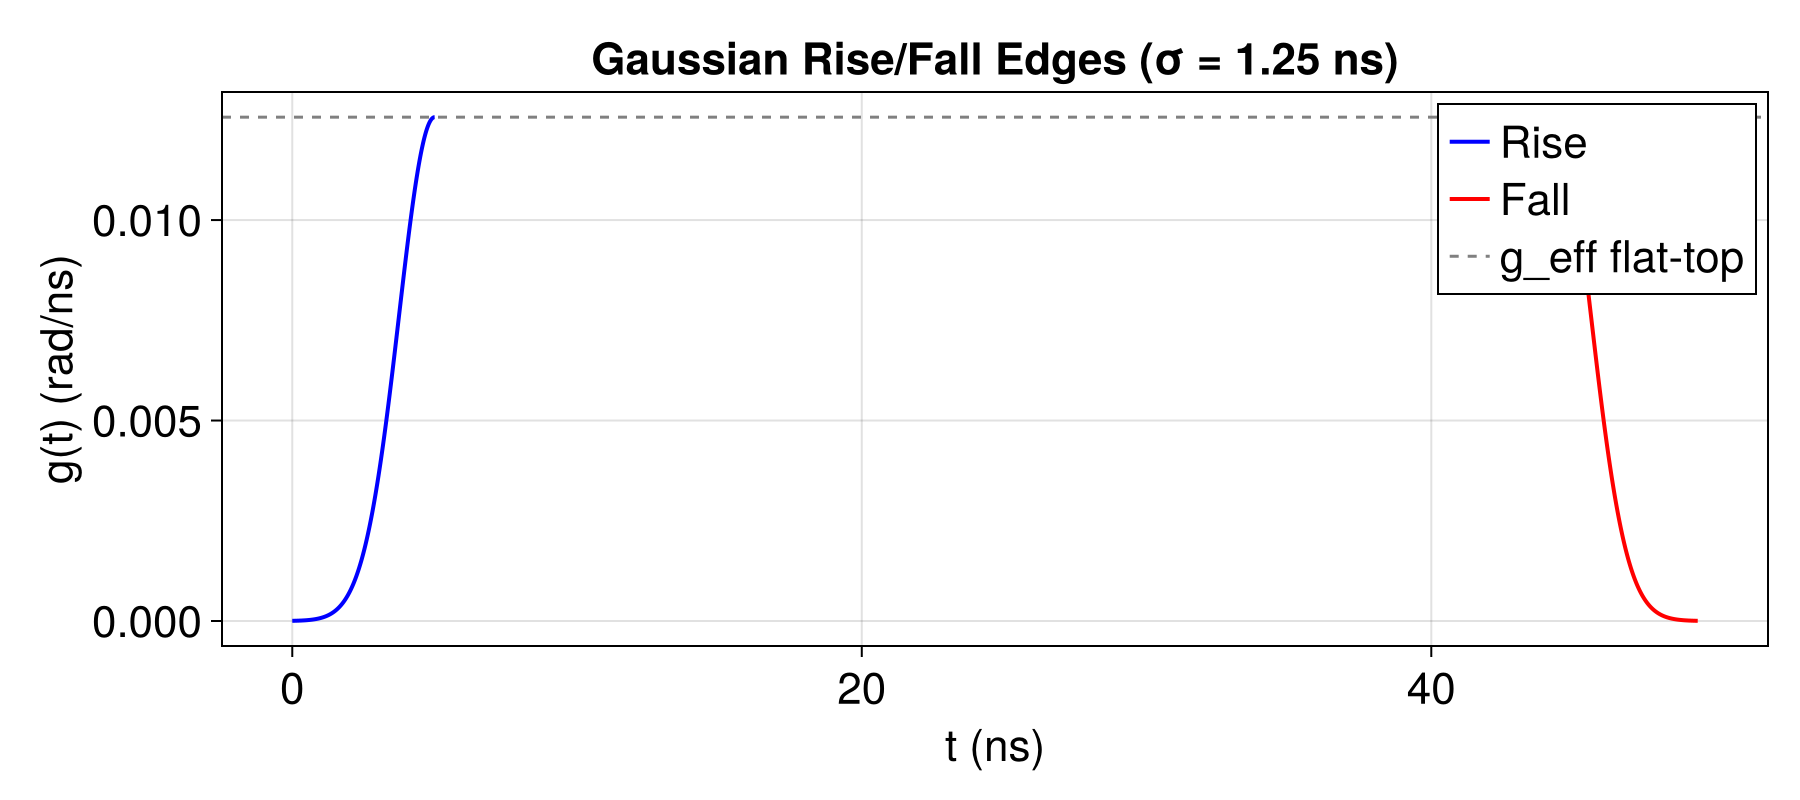

CairoMakie.Screen{IMAGE}


In [5]:
# Plot Gaussian edges
fig = Figure(fontsize=22, size=(900, 400))
ax = Axis(fig[1, 1], xlabel="t (ns)", ylabel="g(t) (rad/ns)",
    title="Gaussian Rise/Fall Edges (σ = $(σ_rise) ns)")
lines!(ax, t_rise, g_rise, label="Rise", linewidth=2, color=:blue)
lines!(ax, t_fall .+ buffer_duration .+ T_flat_est, g_fall, label="Fall", linewidth=2, color=:red)
hlines!(ax, [g_eff], linestyle=:dash, color=:gray, label="g_eff flat-top")
axislegend(ax)
display(fig)

## 4. Gate Frame Hamiltonian

Both qubits on-resonance at ω₁. Drives detuned by Δ_mw1, Δ_mw2.
The coupling is time-independent. The drive operators oscillate at the detuning.

In [6]:
# Gate-frame Hamiltonian for the flat-top region
# H(u, t) = g_eff(XX+YY) + modulated microwave drives
#
# 4 control channels: u = [u_X1, u_Y1, u_X2, u_Y2]
# g_eff is NOT a control — it's in the drift

function H_gate_frame(u, t)
    uX1, uY1, uX2, uY2 = u

    # Drift: constant coupling
    H = g_eff * (XX + YY)

    # Qubit 1 drives (detuned by Δ_mw1)
    c1 = cos(Δ_mw1 * t)
    s1 = sin(Δ_mw1 * t)
    H += uX1 * (XI * c1 + YI * s1)
    H += uY1 * (YI * c1 - XI * s1)

    # Qubit 2 drives (detuned by Δ_mw2)
    c2 = cos(Δ_mw2 * t)
    s2 = sin(Δ_mw2 * t)
    H += uX2 * (IX * c2 + IY * s2)
    H += uY2 * (IY * c2 - IX * s2)

    return H
end

# Variational error generators (time-independent)
H_vars = [
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

varsys = VariationalQuantumSystem(
    H_gate_frame, H_vars, 4, drive_bounds;
    time_dependent = true
)

println("levels = ", varsys.levels,
        "  n_drives = ", varsys.n_drives,
        "  n_vars = ", length(varsys.G_vars),
        "  time_dep = ", varsys.time_dependent)

levels = 4  n_drives = 4  n_vars = 3  time_dep = true


## 5. Robust Optimization (VariationalSplinePulseProblem)

In [7]:
T_f = T_total_ns   # total flat-top duration (set directly in cell 5)
Δt = T_f / N_knots

Random.seed!(42)
controls = 2 .* a_bound .* rand(4, n_samples) .- a_bound
times = collect(LinRange(0.0, T_f, n_samples))

du_init = zeros(4, n_samples)
pulse = CubicSplinePulse(controls, du_init, times)

qcp = VariationalSplinePulseProblem(
    varsys, pulse, U_goal, N_knots;
    Q                     = 0.0,
    Q_r                   = Q_r,
    R                     = 1e-3,
    du_bound              = Inf,
    Δt_bounds             = (Δt, Δt),
    dynamics_spline_order = 3,
    n_path_samples        = 3,
    piccolo_options       = PiccoloOptions(
        timesteps_all_equal = true,
        verbose             = true,
    ),
)

push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_threshold, get_trajectory(qcp))
)

println("Trajectory components: ", keys(get_trajectory(qcp).components))
println("Initial Δt: ", Δt, " ns")
println("Δt bounds: ", (Δt, Δt), "  (locked at total T = $(N_knots*Δt) ns)")

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      dynamics spline order: 3
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283
Trajectory components: (:Ũ⃗, :Δt, :t, :u, :du, :var_Ũ⃗)
Initial Δt: 5.0 ns
Δt bounds: (5.0, 5.0)  (locked at total T = 120.0 ns)


In [8]:
# Initialize unitary trajectory with a consistent rollout
let
    traj    = get_trajectory(qcp)
    us      = traj[:u]
    dus     = traj[:du]              # cubic Hermite tangents (zero at this stage)
    ts      = vec(traj[:t])
    iso_dim = traj.dims[:Ũ⃗]

    nominal_sys = QuantumSystem(H_gate_frame, drive_bounds; time_dependent=true)
    nlp_pulse   = CubicSplinePulse(us, dus, ts)    # cubic Hermite to match NLP
    nlp_qtraj   = UnitaryTrajectory(nominal_sys, nlp_pulse, U_goal)

    Ũ⃗_init = hcat([operator_to_iso_vec(nlp_qtraj(t)) for t in ts]...)

    traj.data[traj.components[:Ũ⃗], :] .= Ũ⃗_init
    rows_var = traj.components[:var_Ũ⃗]
    traj.data[rows_var[1:iso_dim], :] .= Ũ⃗_init

    U_init = iso_vec_to_operator(Ũ⃗_init[:, end])
    F0 = abs2(tr(U_goal' * U_init)) / varsys.levels^2
    @printf("Initial fidelity (rollout init): %.6f\n", F0)
end

Initial fidelity (rollout init): 0.088499


In [9]:
solve!(qcp, max_iter=num_iter, print_level=5,
    options=IpoptOptions(eval_hessian=false,
        output_file="ipopt_robust_iswap_detuned_$(run_tag).log"))

    initializing optimizer...
      building evaluator: 2 integrators, 2 nonlinear constraints
      dynamics constraints: 3680, nonlinear constraints: 553
        integrator 1 jacobian structure: 0.136s
        integrator 2 jacobian structure: 0.047s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.552s
        constraint 2 (NonlinearKnotPointConstraint) jacobian structure: 0.77s
      jacobian structure: 1257076 nonzeros (1.52s)
        integrator 1 hessian structure: 0.085s
        integrator 2 hessian structure: 0.29s
        constraint 1 (CubicHermitePathConstraint) hessian structure: 1.433s
        constraint 2 (NonlinearKnotPointConstraint) hessian structure: 3.66s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.126s
          sub-objective 2 (QuadraticRegularizer): 0.091s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (KnotPointObjective): 0.0s
      

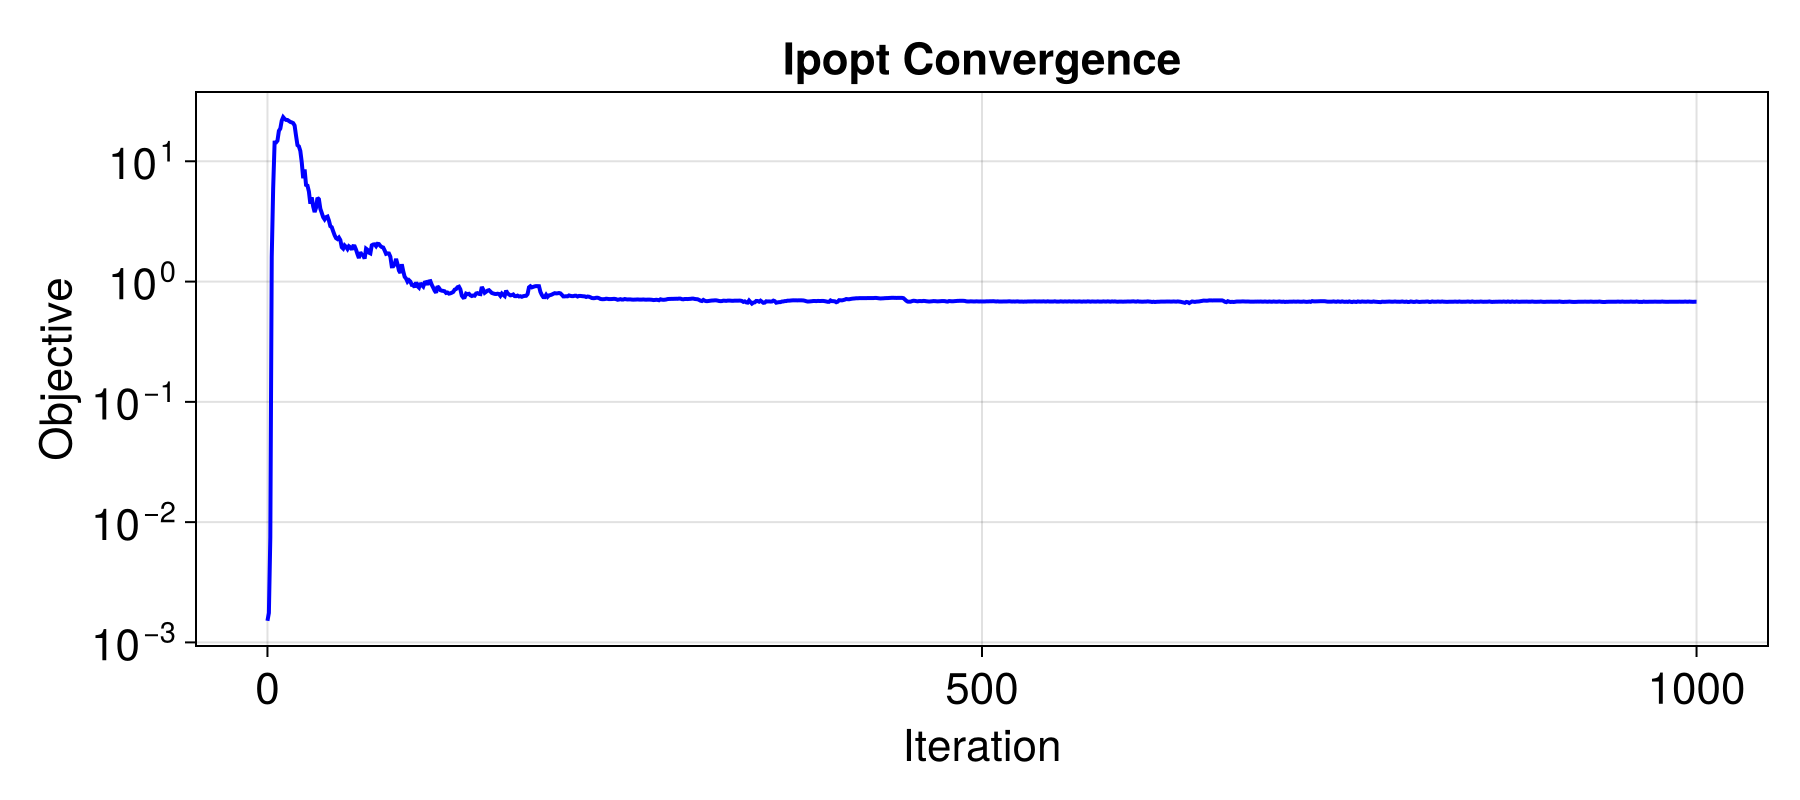

Final objective: 0.67956709 at iteration 1000


In [10]:
# Parse Ipopt log and plot objective vs iteration
log_path = "ipopt_robust_iswap_detuned_$(run_tag).log"
lines_log = readlines(log_path)

iters = Int[]
objs = Float64[]

for line in lines_log
    m = match(r"^\s*(\d+)\s+([\d.e+\-]+)\s+", line)
    if m !== nothing
        push!(iters, parse(Int, m.captures[1]))
        push!(objs, parse(Float64, m.captures[2]))
    end
end

fig = Figure(fontsize=22, size=(900, 400))
ax = Axis(fig[1, 1], xlabel="Iteration", ylabel="Objective",
    title="Ipopt Convergence", yscale=log10)
lines!(ax, iters, objs; linewidth=2, color=:blue)
display(fig)
println("Final objective: ", objs[end], " at iteration ", iters[end])

## 6. Results

In [11]:
traj = get_trajectory(qcp)
U_flat = iso_vec_to_operator(traj[:Ũ⃗][:, end])
F_flat = abs2(tr(U_goal' * U_flat)) / varsys.levels^2
@printf("Flat-top fidelity to U_goal: %.8f\n", F_flat)
@printf("Flat-top infidelity: %.2e\n", 1 - F_flat)

# Full gate verification (includes Gaussian edge + 10 ns buffer on each side)
U_full = V_fall * U_flat * V_rise
F_full = abs2(tr(U_iswap' * U_full)) / 4^2
@printf("Full gate fidelity to iSWAP: %.8f\n", F_full)
@printf("Full gate infidelity: %.2e\n", 1 - F_full)

# Optimized Δt
println("Optimized Δt: ", traj[:t][2] - traj[:t][1], " ns")
println("Optimized T_flat (microwave region): ", traj[:t][end], " ns")

# Total gate time: 2 × (Gaussian edge) + 2 × (flat buffer) + microwave flat-top
T_total = 2 * buffer_duration + 2 * buffer_flat_duration + traj[:t][end]
println("Total gate time = ", round(T_total, digits=2), " ns",
        "  (", round(buffer_duration), " Gauss + ", round(buffer_flat_duration), " buf + ",
        round(traj[:t][end]), " mw + ", round(buffer_flat_duration), " buf + ",
        round(buffer_duration), " Gauss)")

# Virtual Z correction (accumulated phase from idle detuning over the full gate)
φ_vz = δ₁₂ * T_total
println("Virtual Z on q2: Rz(", round(φ_vz, digits=4), " rad) = Rz(",
    round(φ_vz/(2π), digits=4), " × 2π)")

Flat-top fidelity to U_goal: 0.99990110
Flat-top infidelity: 9.89e-05
Full gate fidelity to iSWAP: 0.99990110
Full gate infidelity: 9.89e-05
Optimized Δt: 5.0 ns
Optimized T_flat (microwave region): 115.0 ns
Total gate time = 145.0 ns  (5.0 Gauss + 10.0 buf + 115.0 mw + 10.0 buf + 5.0 Gauss)
Virtual Z on q2: Rz(54.6637 rad) = Rz(8.7 × 2π)


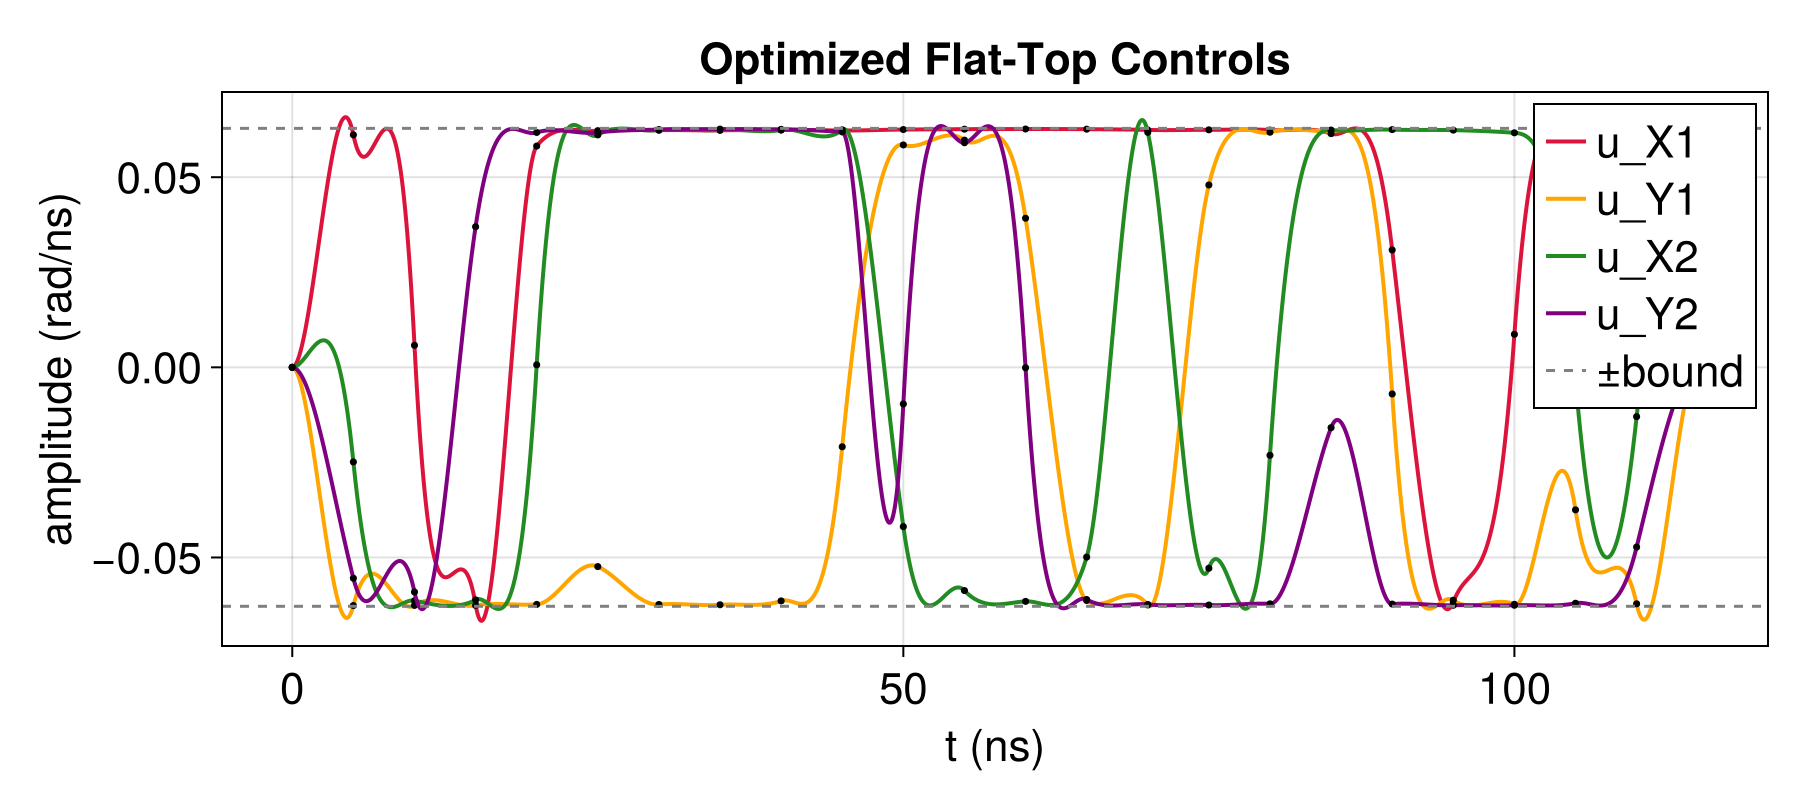

CairoMakie.Screen{IMAGE}


In [12]:
# Plot optimized controls
function _spline_fine(traj)
    ts_knots = vec(traj[:t])
    us_knots = traj[:u]
    du_knots = traj[:du]
    pulse    = CubicSplinePulse(us_knots, du_knots, ts_knots)
    ts_fine  = collect(LinRange(ts_knots[1], ts_knots[end], 2000))
    us_fine  = sample(pulse, ts_fine)
    return ts_knots, us_knots, ts_fine, us_fine
end

ts_knots, us_knots, ts_fine, us_fine = _spline_fine(traj)

labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
colors_ctrl = [:crimson, :orange, :forestgreen, :purple]

fig = Figure(size=(900, 400), fontsize=22)
ax = Axis(fig[1, 1], xlabel="t (ns)", ylabel="amplitude (rad/ns)",
    title="Optimized Flat-Top Controls")

for (i, (lbl, col)) in enumerate(zip(labels, colors_ctrl))
    lines!(ax, ts_fine, vec(us_fine[i, :]); label=lbl, color=col, linewidth=2)
    scatter!(ax, ts_knots, vec(us_knots[i, :]); color=:black, markersize=5)
end
hlines!(ax, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")
axislegend(ax, position=:rt)
display(fig)

## 6b. Default Baseline: Gaussian Square (no microwaves)

The default iSWAP is a Gaussian square pulse on g_eff only — same edge shape
(σ_rise), but with a flat-top duration chosen so the total area ∫g(t)dt = π/4.
No microwave drives. This is what experiment would do without robust control.

In [13]:
# --- Build Gaussian square pulse (coupling only, no microwaves) ---
# Same σ_rise edges, find flat-top width so total area = π/4

function gaussian_square_area(flat_ns; g_eff=g_eff, σ=σ_rise, dt=0.01, trunc=4)
    buf = trunc * σ
    # Rise: g_eff * exp(-(t - buf)² / (2σ²)) for t ∈ [0, buf]
    t_rise = collect(0:dt:buf)
    g_rise_seg = g_eff .* exp.(-(t_rise .- buf).^2 ./ (2σ^2))
    A_rise = sum(g_rise_seg) * dt

    # Flat-top
    A_flat = g_eff * flat_ns

    # Fall: same as rise by symmetry
    A_fall = A_rise

    return A_rise + A_flat + A_fall
end

# Bisect to find flat-top width giving total area = π/4
let target = π/4, lo = 0.0, hi = 400.0
    for _ in 1:100
        mid = (lo + hi) / 2
        gaussian_square_area(mid) < target ? (lo = mid) : (hi = mid)
    end
    global flat_default = (lo + hi) / 2
end

println("Default Gaussian square flat-top width: ", round(flat_default, digits=4), " ns")
println("Total area check: ", round(gaussian_square_area(flat_default), digits=8),
        " (π/4 = ", round(π/4, digits=8), ")")

# --- Build the full default pulse on a fine time grid ---
buf = 4 * σ_rise
dt_default = 0.01
T_default = buf + flat_default + buf

t_default = collect(0:dt_default:T_default)
g_default = zeros(length(t_default))

for (i, t) in enumerate(t_default)
    if t < buf
        # Rising edge
        g_default[i] = g_eff * exp(-(t - buf)^2 / (2σ_rise^2))
    elseif t < buf + flat_default
        # Flat-top
        g_default[i] = g_eff
    else
        # Falling edge
        t_fall = t - buf - flat_default
        g_default[i] = g_eff * exp(-t_fall^2 / (2σ_rise^2))
    end
end

println("Default total gate time: ", round(T_default, digits=2), " ns")
println("Default total area: ", round(sum(g_default)*dt_default, digits=8))

Default Gaussian square flat-top width: 59.3569 ns
Total area check: 0.78539816 (π/4 = 0.78539816)
Default total gate time: 69.36 ns
Default total area: 0.78527247


## 7. Robustness Verification: Default vs Robust


In [14]:
# --- Robustness sweep setup ---
εs         = collect(range(-0.02, 0.02, length=101))
errors     = [(ZI, "ZI"), (IZ, "IZ"), (ZZ, "ZZ")]
err_colors = [:red, :blue, :green]

F_vs_eps         = Dict{String, Vector{Float64}}()
F_default_vs_eps = Dict{String, Vector{Float64}}()

outdir = "robust_iswap_detuned_$(run_tag)"
mkpath(joinpath(outdir, "figs"))                                                                                                                                       

"robust_iswap_detuned_2MHz_120nsmw_5nsgauss_10nsbuf/figs"

In [16]:
# --- Simulate full robust gate (V_rise + flat-top + V_fall) WITH error ---
# V_rise / V_fall now each cover 15 ns: 5 ns Gaussian + 10 ns flat at g_eff.
# Microwaves are zero during these regions; only the coupling (and error) act.

function simulate_edge_unitary(g_pulse, t_pulse, dt, ε_op, ε_val)
    N = length(g_pulse)
    T_ns = t_pulse[end]

    function H_edge_err(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end

    edge_sys = QuantumSystem(H_edge_err, Float64[]; time_dependent=true)
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)
    qtraj = UnitaryTrajectory(edge_sys, dummy_pulse, Matrix{ComplexF64}(I, 4, 4))
    return qtraj(T_ns)
end

# --- Build the rise-side pulse: 5 ns Gaussian (ramp up) + 10 ns flat at g_eff ---
dt_edge = 0.01
gauss_ns_fine = buffer_duration             # 5 ns Gaussian portion
buf_ns_fine   = buffer_flat_duration        # 10 ns flat portion
edge_total    = gauss_ns_fine + buf_ns_fine # 15 ns each side

t_rise_fine = collect(0:dt_edge:edge_total)
g_rise_fine = [
    t < gauss_ns_fine ?
        g_eff * exp(-(t - gauss_ns_fine)^2 / (2 * σ_rise^2)) :   # Gaussian ramp
        g_eff                                                     # flat at g_eff
    for t in t_rise_fine
]

# --- Build the fall-side pulse: 10 ns flat at g_eff + 5 ns Gaussian (ramp down) ---
t_fall_fine = collect(0:dt_edge:edge_total)
g_fall_fine = [
    t < buf_ns_fine ?
        g_eff :                                                                # flat at g_eff
        g_eff * exp(-(t - buf_ns_fine)^2 / (2 * σ_rise^2))                     # Gaussian ramp down
    for t in t_fall_fine
]

function simulate_full_gate_fidelity(traj, ε_op, ε_val)
    V_rise_err = simulate_edge_unitary(g_rise_fine, t_rise_fine, dt_edge, ε_op, ε_val)
    V_fall_err = simulate_edge_unitary(g_fall_fine, t_fall_fine, dt_edge, ε_op, ε_val)

    ts  = vec(traj[:t])
    us  = traj[:u]
    dus = traj[:du]

    function H_with_error(u, t)
        return H_gate_frame(u, t) + ε_val * ε_op
    end

    err_sys    = QuantumSystem(H_with_error, drive_bounds; time_dependent=true)
    nlp_pulse  = CubicSplinePulse(us, dus, ts)
    qtraj      = UnitaryTrajectory(err_sys, nlp_pulse, U_goal)
    U_flat_err = qtraj(ts[end])

    U_full_err = V_fall_err * U_flat_err * V_rise_err
    return abs2(tr(U_iswap' * U_full_err)) / 4^2
end

for (err_op, err_name) in errors
    F_curve = Float64[]
    for ε in εs
        push!(F_curve, simulate_full_gate_fidelity(traj, err_op, ε))
    end
    F_vs_eps[err_name] = F_curve
    println("Robust $err_name sweep complete")
end

Robust ZI sweep complete
Robust IZ sweep complete
Robust ZZ sweep complete


In [17]:
 # --- Simulate default Gaussian-square pulse with errors everywhere ---                                                                                                                                 
 function simulate_default_fidelity(g_pulse, t_pulse, dt, ε_op, ε_val)                                                                                                                                   
    N = length(g_pulse)
    T_ns = t_pulse[end]                                                                                                                                                                                 
                                                                                                                                                                                                        
    function H_default(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)                                                                                                                                                       
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end                                                                                                                                                                                                 
 
    def_sys = QuantumSystem(H_default, Float64[]; time_dependent=true)                                                                                                                                  
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)                                                                                                                                 
    qtraj = UnitaryTrajectory(def_sys, dummy_pulse, U_iswap)                                                                                                                                            
    U_def = qtraj(T_ns)                                                                                                                                                                                 
    return abs2(tr(U_iswap' * U_def)) / 4^2                                                                                                                                                             
end                                                                                                                                                                                                     
 
for (err_op, err_name) in errors                                                                                                                                                                        
    F_curve = Float64[]
    for ε in εs
        push!(F_curve, simulate_default_fidelity(g_default, t_default, dt_default, err_op, ε))
    end                                                                                                                                                                                                 
    F_default_vs_eps[err_name] = F_curve
    println("Default $err_name sweep complete")                                                                                                                                                         
end                      

Default ZI sweep complete
Default IZ sweep complete
Default ZZ sweep complete


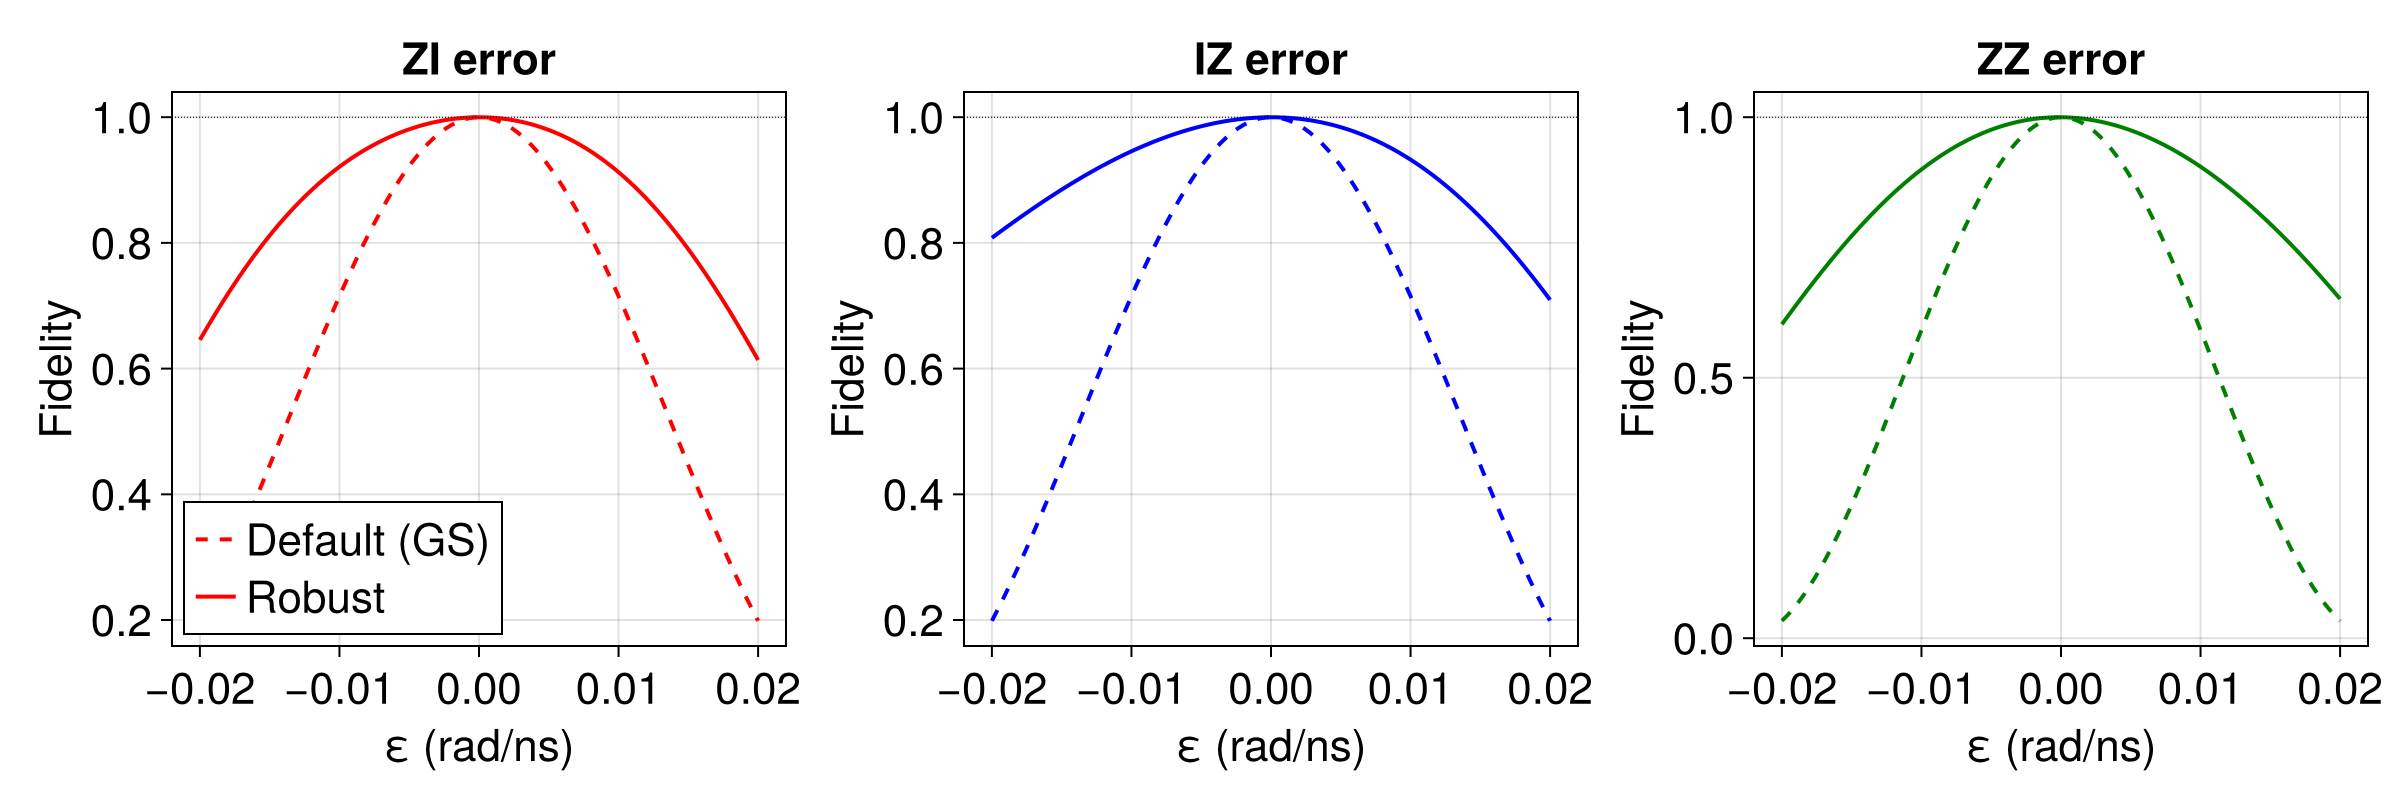

In [18]:
# Plot fidelity comparison: default vs robust (linear)
fig = Figure(fontsize=22, size=(1200, 400))

for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))
    ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="Fidelity",
        title="$err_name error")
    lines!(ax, εs, F_default_vs_eps[err_name];
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")
    lines!(ax, εs, F_vs_eps[err_name];
        color=ecol, linewidth=2, label="Robust")
    hlines!(ax, [F_threshold]; linestyle=:dot, color=:black, linewidth=0.5)
    if col == 1; axislegend(ax, position=:lb); end
end

display(fig)
save(joinpath(outdir, "figs", "default_vs_robust.png"), fig)


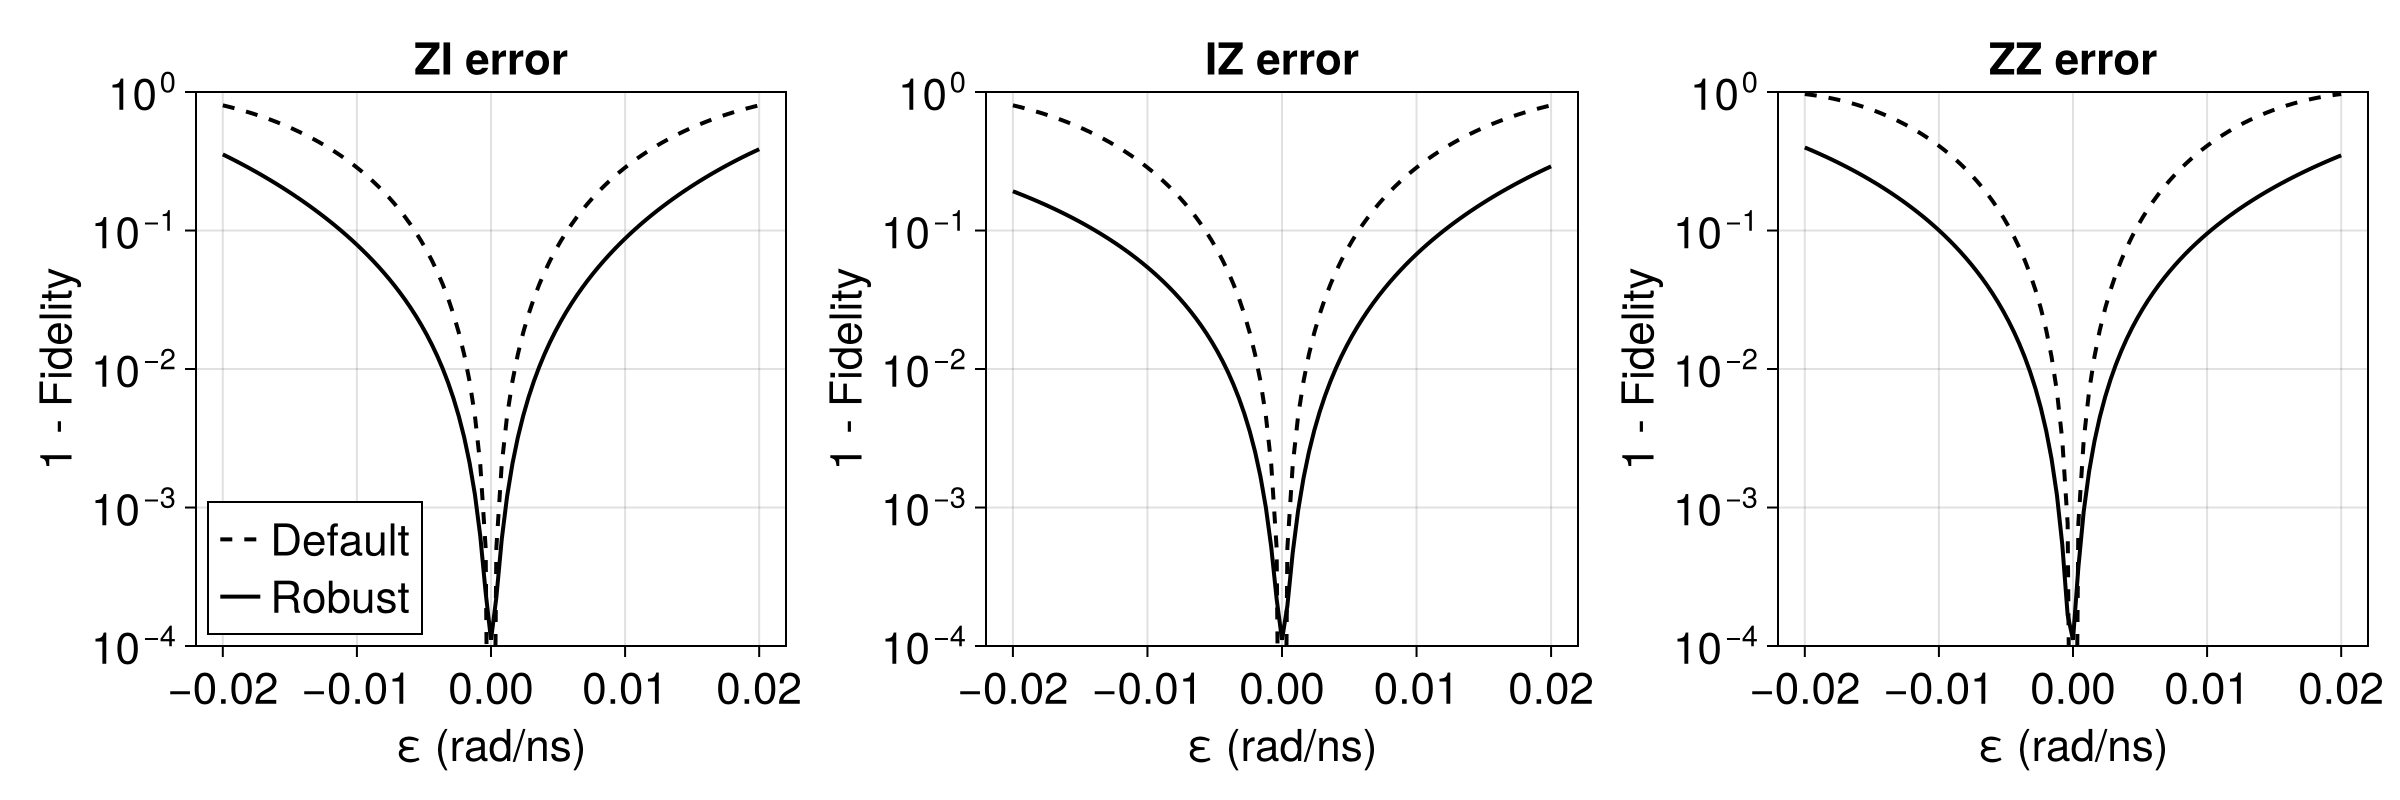

In [19]:
  # Plot infidelity comparison: default vs robust (log scale)
  fig = Figure(fontsize=22, size=(1200, 400))                                                                                                                                                             
   
  for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))                                                                                                                             
      ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="1 - Fidelity",
          title="$err_name error", yscale=log10)                                                                                                                                                          
      lines!(ax, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
          color=:black, linewidth=2, linestyle=:dash, label="Default")                                                                                                                                    
      lines!(ax, εs, max.(1 .- F_vs_eps[err_name], 1e-16);                                                                                                                                                
          color=:black, linewidth=2, label="Robust")
      ylims!(ax, 1e-4, 1.0)                                                                                                                                                                               
      if col == 1; axislegend(ax, position=:lb); end
  end                                                                                                                                                                                                     
                  
  display(fig)                                                                                                                                                                                            
  save(joinpath(outdir, "figs", "default_vs_robust_log.png"), fig)

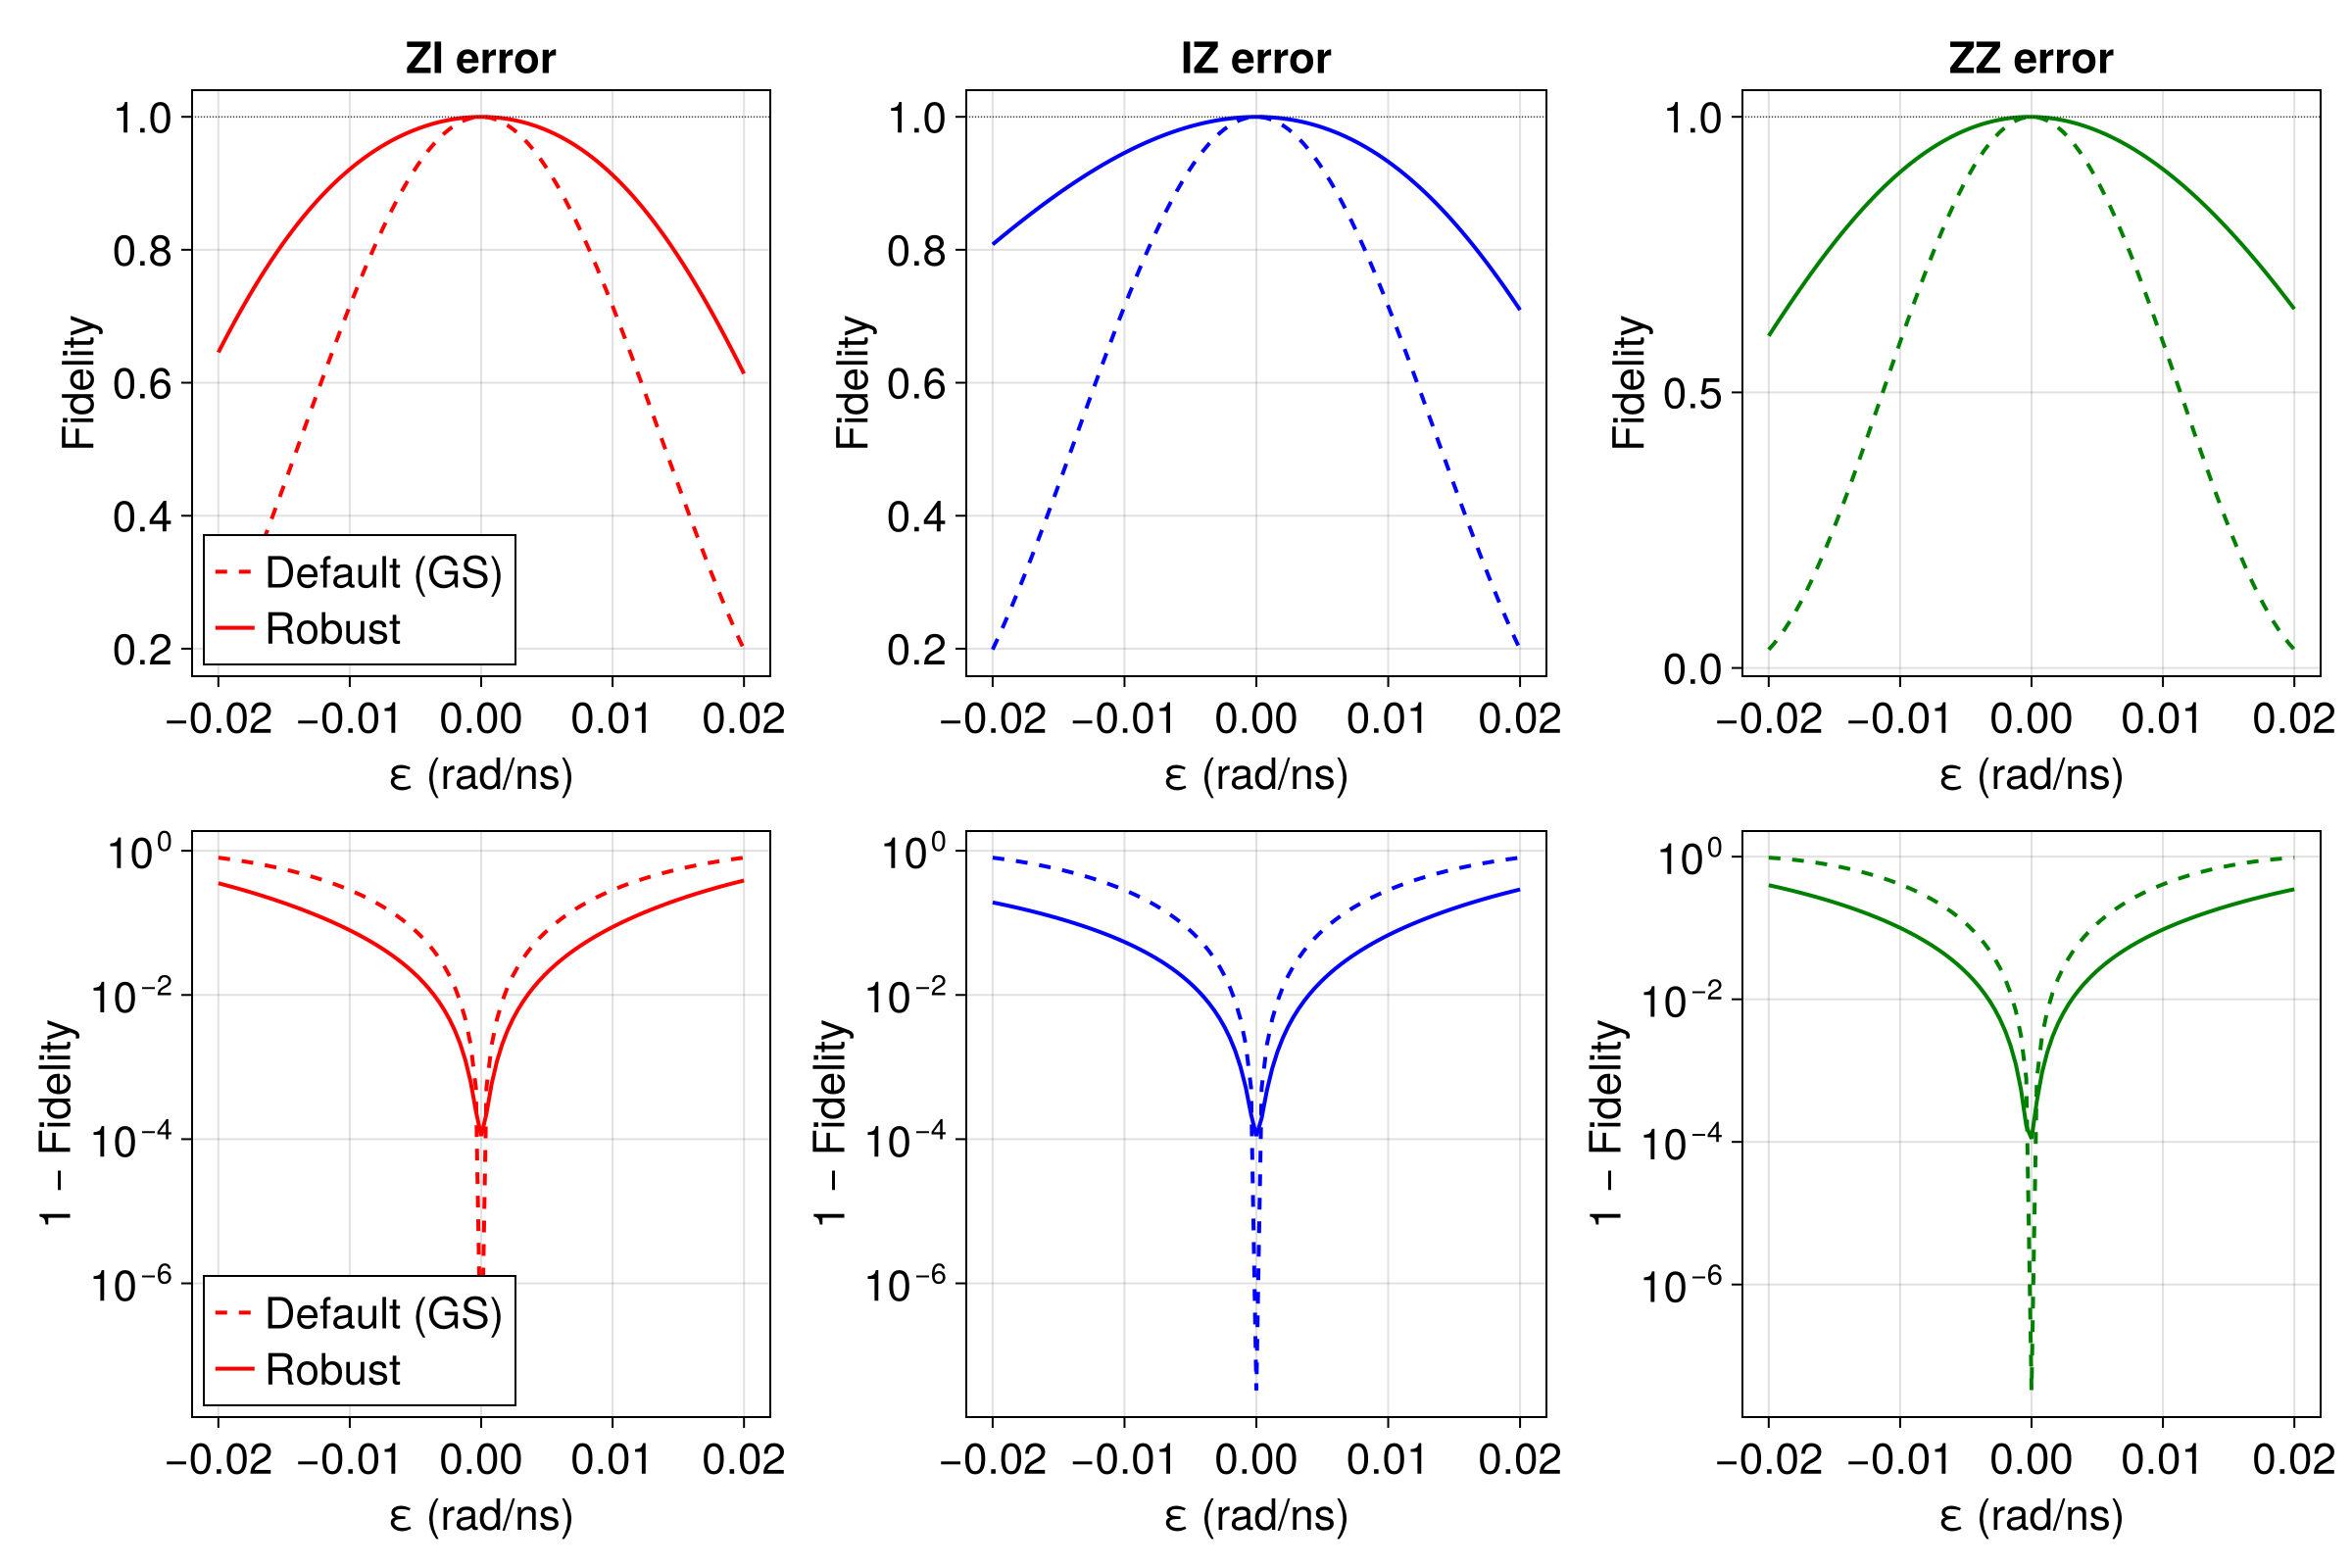

In [20]:
# Plot fidelity comparison: default vs robust (linear top, log infidelity bottom)                                               
fig = Figure(fontsize=22, size=(1200, 800))                                                                                     
                                                                                                                                                                                                          
for (col, ((err_op, err_name), ecol)) in enumerate(zip(errors, err_colors))                                                                                                                             
    # Top row — linear fidelity                                                                                                                                                                         
    ax_lin = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="Fidelity",                                                                                                                                  
        title="$err_name error")                                                                                                                                                                        
    lines!(ax_lin, εs, F_default_vs_eps[err_name];
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")                                                                                                                                 
    lines!(ax_lin, εs, F_vs_eps[err_name];
        color=ecol, linewidth=2, label="Robust")                                                                                                                                                        
    hlines!(ax_lin, [F_threshold]; linestyle=:dot, color=:black, linewidth=0.5)
    if col == 1; axislegend(ax_lin, position=:lb); end                                                                                                                                                  
                
    # Bottom row — log infidelity                                                                                                                                                                       
    ax_log = Axis(fig[2, col], xlabel="ε (rad/ns)", ylabel="1 − Fidelity",
        yscale=log10)                                                                                                                                                                                   
    lines!(ax_log, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
        color=ecol, linewidth=2, linestyle=:dash, label="Default (GS)")                                                                                                                                 
    lines!(ax_log, εs, max.(1 .- F_vs_eps[err_name], 1e-16);
        color=ecol, linewidth=2, label="Robust")                                                                                                                                                        
    if col == 1; axislegend(ax_log, position=:lb); end
end                                                                                                                                                                                                     
                                                                                                                                                                                                        
# Link x-axes column-wise so panning matches across rows                                                                                                                                                
for col in 1:length(errors)                                                                                                                                                                             
    linkxaxes!(contents(fig[1, col])[1], contents(fig[2, col])[1])                                                                                                                                      
end

display(fig)                                                                                                                                                                                            
save(joinpath(outdir, "figs", "default_vs_robust_6panel.png"), fig)

## 8. Save Results

In [21]:
using DelimitedFiles                                                                                                            
                                                                                                                                                                                                                                                                                               
                                                                                                                                                                                                        
  # Save controls (transposed — rows = time, columns = channels)                                                                                                                                      
  ts_knots_save, us_knots_save, ts_fine_save, us_fine_save = _spline_fine(traj)                                                                                                                         
                                                                                                                                                                                                        
  open(joinpath(outdir, "controls_fine.csv"), "w") do io
      println(io, "time_ns,u_X1,u_Y1,u_X2,u_Y2")                                                                                                                                                        
      for j in 1:length(ts_fine_save)                                                                                                                                                                   
          println(io, "$(ts_fine_save[j]),$(us_fine_save[1,j]),$(us_fine_save[2,j]),$(us_fine_save[3,j]),$(us_fine_save[4,j])")
      end                                                                                                                                                                                               
  end                                                                                                                                                                                                   
                                                                                                                                                                                                        
  # Save fidelity curves                                                                                                                                                                                
  for (err_op, err_name) in errors
      open(joinpath(outdir, "fidelity_$(err_name).csv"), "w") do io
          println(io, "epsilon,fidelity")
          for (ε, F_val) in zip(εs, F_vs_eps[err_name])
              println(io, "$ε,$F_val")                                                                                                                                                                  
          end
      end                                                                                                                                                                                               
  end             

  # Save parameters
  open(joinpath(outdir, "parameters.txt"), "w") do io
      println(io, "g_eff = $g_eff rad/ns ($(round(g_eff/(2π)*1e3, digits=1)) MHz)")                                                                                                                     
      println(io, "δ₁₂ = $δ₁₂ rad/ns ($(round(δ₁₂/(2π)*1e3, digits=1)) MHz)")
      println(io, "Δ_mw1 = $Δ_mw1 rad/ns ($(round(Δ_mw1/(2π)*1e3, digits=1)) MHz)")                                                                                                                     
      println(io, "Δ_mw2 = $Δ_mw2 rad/ns ($(round(Δ_mw2/(2π)*1e3, digits=1)) MHz)")                                                                                                                     
      println(io, "a_bound = $a_bound rad/ns ($(round(a_bound/(2π)*1e3, digits=1)) MHz)")                                                                                                               
      println(io, "σ_rise = $σ_rise ns")                                                                                                                                                                
      println(io, "buffer_duration = $buffer_duration ns")                                                                                                                                              
      println(io, "A_rise = $A_rise rad")
      println(io, "A_fall = $A_fall rad")                                                                                                                                                               
      println(io, "θ_goal = $θ_goal rad")                                                                                                                                                             
      println(io, "T_flat = $(traj[:t][end]) ns")                                                                                                                                                       
      println(io, "T_total = $T_total ns")
      println(io, "F_threshold = $F_threshold")                                                                                                                                                         
      println(io, "Virtual Z on q2 = $(φ_vz) rad")                                                                                                                                                      
  end
                                                                                                                                                                                                        
  println("Saved to: ", abspath(outdir))

UndefVarError: UndefVarError: `A_rise` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

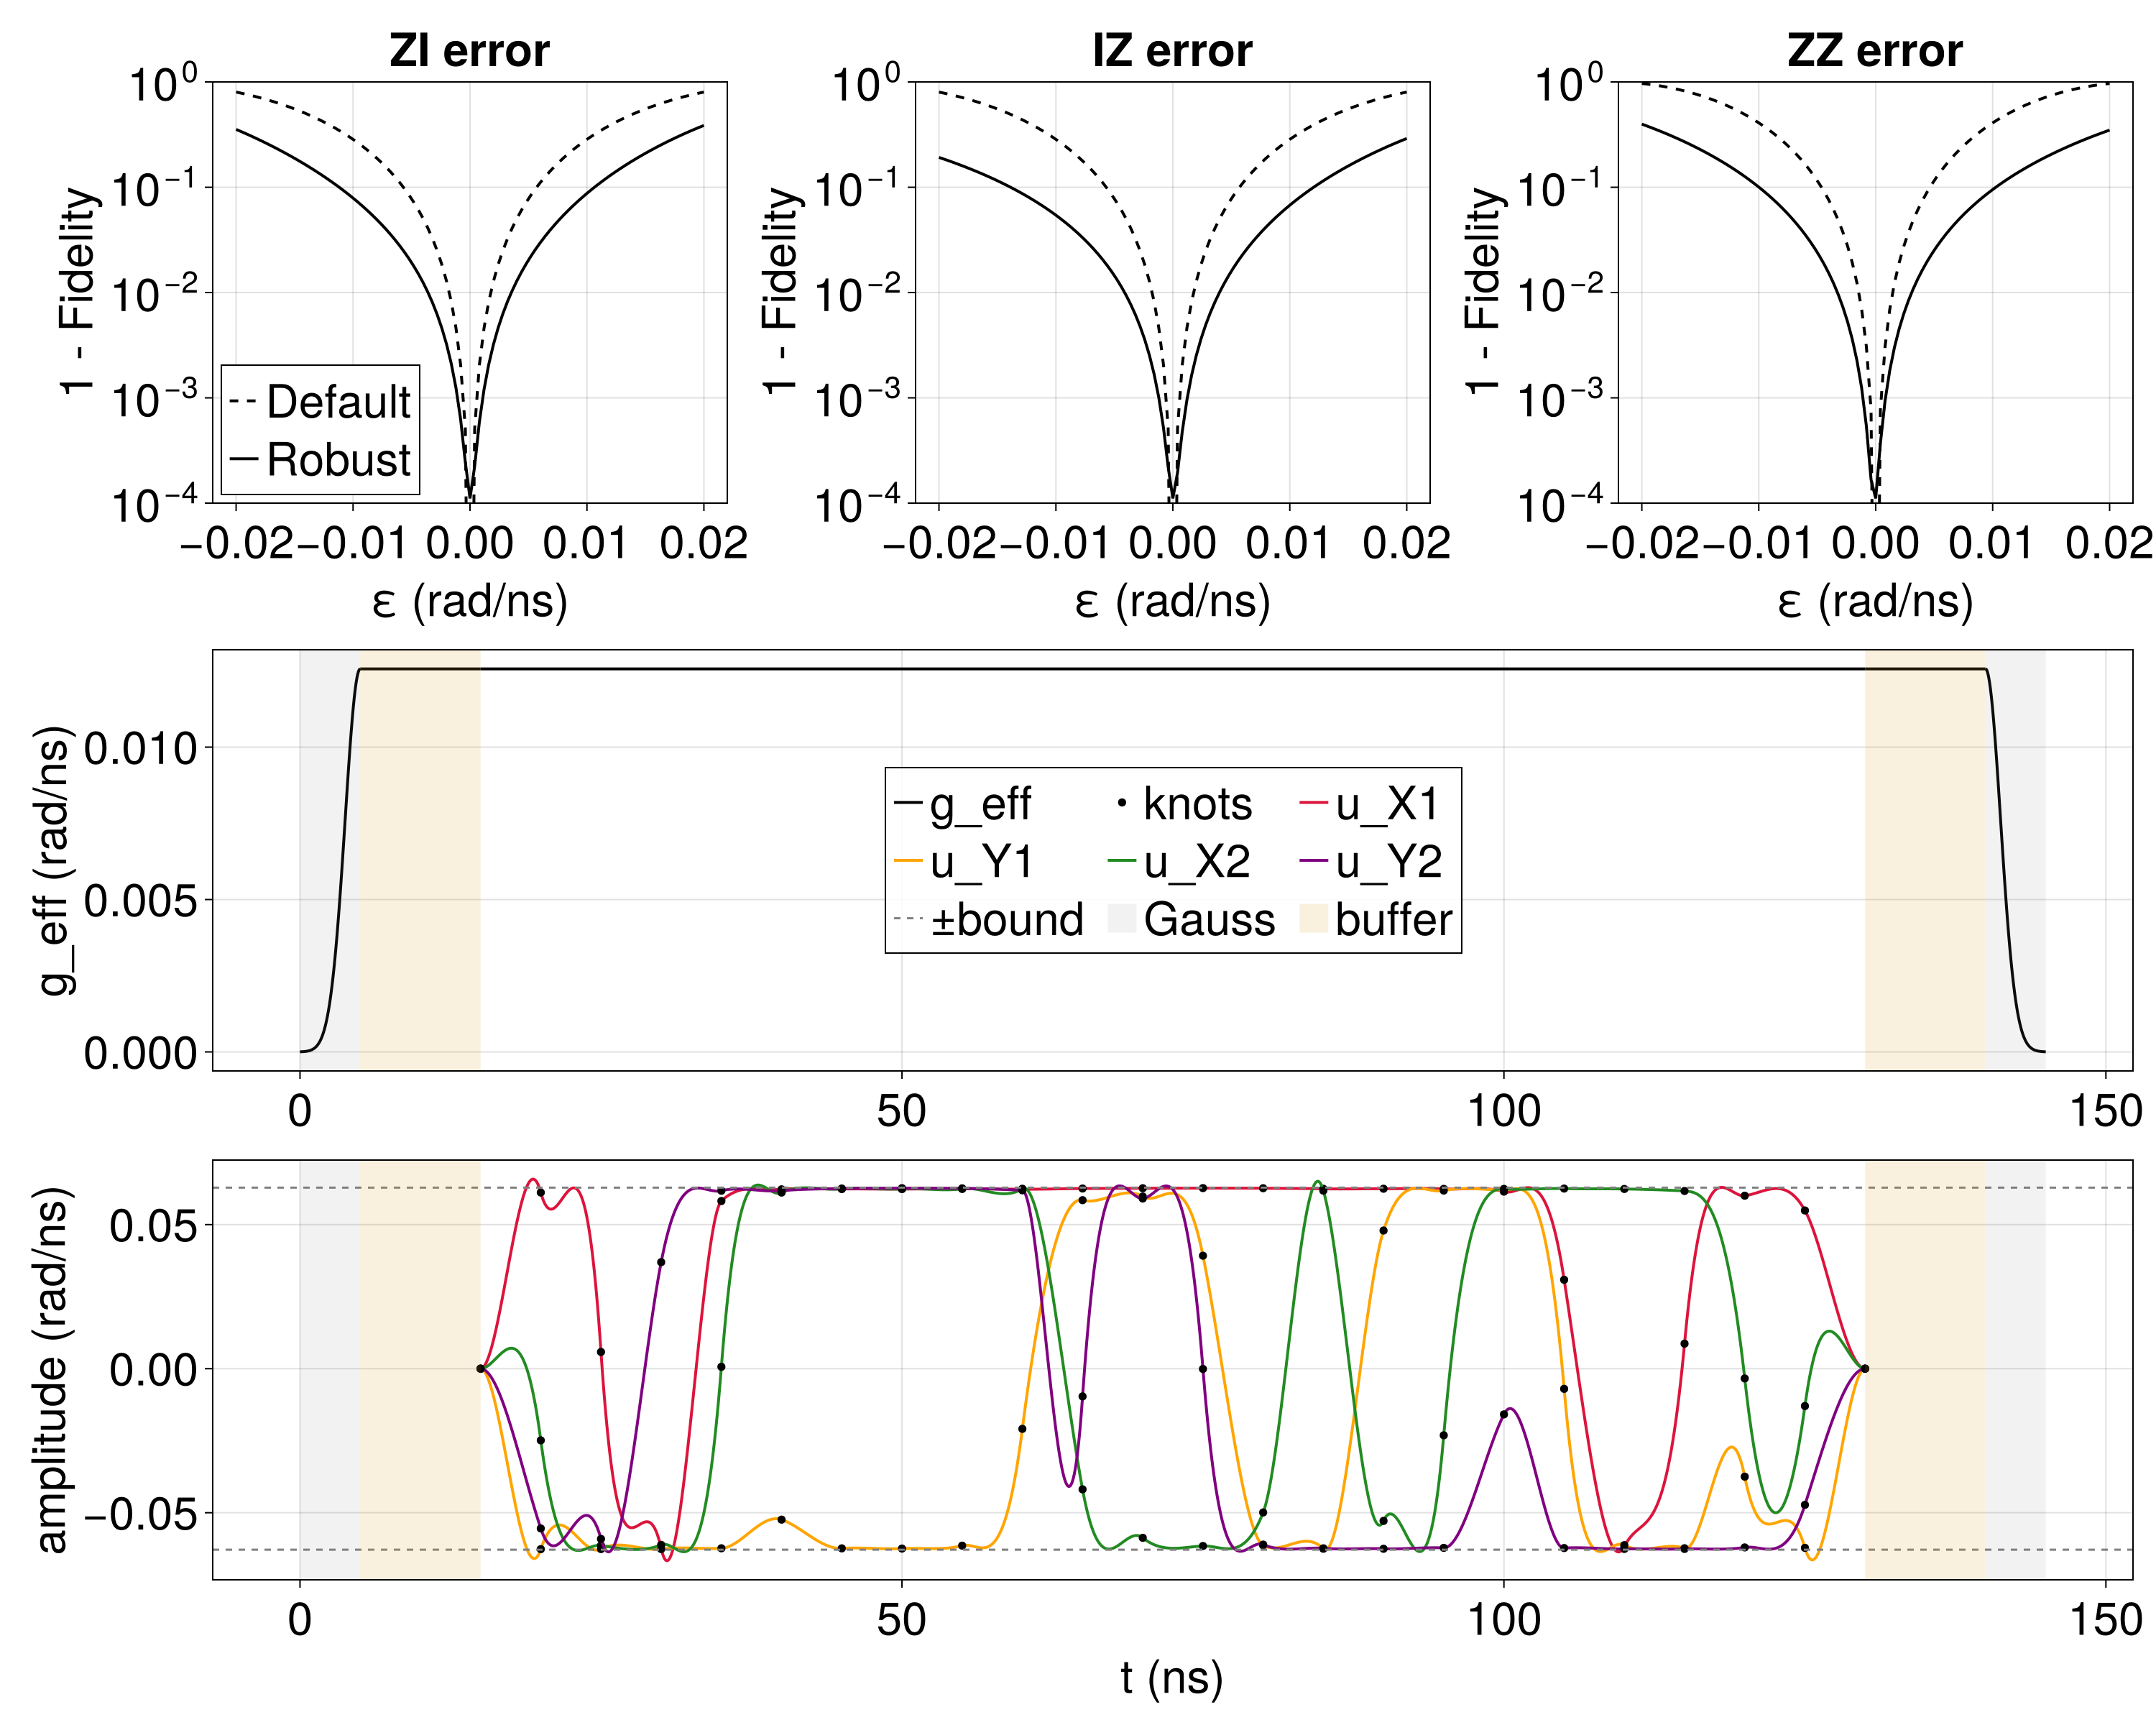

In [26]:
# Combined: full pulse (g_eff envelope + microwaves) + infidelity comparison
ts_knots, us_knots, ts_fine_mw, us_fine_mw = _spline_fine(traj)
T_flat_opt = ts_fine_mw[end]

# Time-axis offsets matching the layout:
# [Gauss rise | buffer | microwaves | buffer | Gauss fall]
# 0           σ4        σ4+buf      σ4+buf+T  σ4+2buf+T   2σ4+2buf+T
mw_start = buffer_duration + buffer_flat_duration                 # start of microwave region (= 15 ns)
mw_end   = mw_start + T_flat_opt                                  # end of microwave region
gate_end = mw_end + buffer_flat_duration + buffer_duration        # total gate end

dt_plot = 0.05

t_gauss_rise = collect(0:dt_plot:buffer_duration)
t_buf_pre    = collect(0:dt_plot:buffer_flat_duration) .+ buffer_duration
t_mw         = collect(0:dt_plot:T_flat_opt) .+ mw_start
t_buf_post   = collect(0:dt_plot:buffer_flat_duration) .+ mw_end
t_gauss_fall = collect(0:dt_plot:buffer_duration) .+ mw_end .+ buffer_flat_duration

g_gauss_rise = g_eff .* exp.(-(t_gauss_rise .- buffer_duration).^2 ./ (2σ_rise^2))
g_buf_pre    = fill(g_eff, length(t_buf_pre))
g_mw         = fill(g_eff, length(t_mw))
g_buf_post   = fill(g_eff, length(t_buf_post))
g_gauss_fall = g_eff .* exp.(-(t_gauss_fall .- mw_end .- buffer_flat_duration).^2 ./ (2σ_rise^2))

FS = 32
fig = Figure(size=(1500, 1200), fontsize=FS)

# --- Row 2: g_eff envelope (spans 3 columns) ---
ax1 = Axis(fig[2, 1:3], ylabel="g_eff (rad/ns)")
lines!(ax1, t_gauss_rise, g_gauss_rise; color=:black, linewidth=2)
lines!(ax1, t_buf_pre,    g_buf_pre;    color=:black, linewidth=2)
lines!(ax1, t_mw,         g_mw;         color=:black, linewidth=2, label="g_eff")
lines!(ax1, t_buf_post,   g_buf_post;   color=:black, linewidth=2)
lines!(ax1, t_gauss_fall, g_gauss_fall; color=:black, linewidth=2)
# Shade Gaussian edges in lighter gray, buffers in slightly darker gray
vspan!(ax1, [0],                                 [buffer_duration];                              color=(:gray, 0.1))
vspan!(ax1, [buffer_duration],                   [mw_start];                                     color=(:goldenrod, 0.15))
vspan!(ax1, [mw_end],                            [mw_end + buffer_flat_duration];                color=(:goldenrod, 0.15))
vspan!(ax1, [mw_end + buffer_flat_duration],     [gate_end];                                     color=(:gray, 0.1))

# --- Row 3: microwave controls (only in mw region) ---
ax2 = Axis(fig[3, 1:3], xlabel="t (ns)", ylabel="amplitude (rad/ns)")
mw_labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
mw_colors = [:crimson, :orange, :forestgreen, :purple]

for (i, (lbl, c)) in enumerate(zip(mw_labels, mw_colors))
    lines!(ax2, ts_fine_mw .+ mw_start, vec(us_fine_mw[i, :]);
        label=lbl, color=c, linewidth=2)
    scatter!(ax2, ts_knots .+ mw_start, vec(us_knots[i, :]);
        color=:black, markersize=8,
        label = i == 1 ? "knots" : nothing)
end
hlines!(ax2, [a_bound, -a_bound]; linestyle=:dash, color=:gray, label="±bound")
vspan!(ax2, [0],                                 [buffer_duration];                              color=(:gray, 0.1), label="Gauss")
vspan!(ax2, [buffer_duration],                   [mw_start];                                     color=(:goldenrod, 0.15), label="buffer")
vspan!(ax2, [mw_end],                            [mw_end + buffer_flat_duration];                color=(:goldenrod, 0.15))
vspan!(ax2, [mw_end + buffer_flat_duration],     [gate_end];                                     color=(:gray, 0.1))

linkxaxes!(ax1, ax2)

# Combined pulse-plot legend
all_plots, all_labels = [], String[]
for ax in (ax1, ax2)
    for p in ax.scene.plots
        if haskey(p.attributes, :label)
            lbl = p.attributes[:label][]
            if lbl !== nothing && !isempty(string(lbl))
                push!(all_plots, p)
                push!(all_labels, string(lbl))
            end
        end
    end
end

# Reorder: g_eff first, knots second, Gauss/buffer last
desired_first = ["g_eff", "knots"]
ordered_plots, ordered_labels = [], String[]
for lbl in desired_first
    idx = findfirst(==(lbl), all_labels)
    if idx !== nothing
        push!(ordered_plots, all_plots[idx])
        push!(ordered_labels, all_labels[idx])
    end
end
for (p, lbl) in zip(all_plots, all_labels)
    if !(lbl in desired_first)
        push!(ordered_plots, p)
        push!(ordered_labels, lbl)
    end
end

Legend(fig[2, 1:3], ordered_plots, ordered_labels;
    halign          = :center,
    valign          = :center,
    tellwidth       = false,
    tellheight      = false,
    framevisible    = true,
    backgroundcolor = (:white, 0.85),
    nbanks          = 3,
    labelsize       = FS,
)

# --- Row 1: infidelity comparison (one column per error) ---
for (col, (err_op, err_name)) in enumerate(errors)
    ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="1 - Fidelity",
        title="$err_name error", yscale=log10)
    lines!(ax, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
        color=:black, linewidth=2, linestyle=:dash, label="Default")
    lines!(ax, εs, max.(1 .- F_vs_eps[err_name], 1e-16);
        color=:black, linewidth=2, label="Robust")
    ylims!(ax, 1e-4, 1.0)
    if col == 1
        axislegend(ax, position=:lb, labelsize=FS)
    end
end

display(fig)
save(joinpath(outdir, "figs", "combined.png"), fig)